# Figure 3

## Timestamps

Heatmap: Last generated 3/12/2026 at 2:00pm
Scatterplot: Last generated 3/12/2026 at 2:00pm

## Code to calculate the RBP Activity Metric and generate heatmap figure

### Load packages and read in table

In [1]:
import polars as pl
_=pl.Config.set_tbl_cols(100000)
_=pl.Config.set_tbl_rows(10000)
_=pl.Config.set_tbl_width_chars(10000)
_=pl.Config.set_fmt_str_lengths(10000)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, BoundaryNorm
import seaborn as sns
import pickle

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [2]:
# Function to get path for big table

from pathlib import Path

def get_path(cell_line: str, path_file: str = "data_path.txt") -> str:
    """
    Reads a base directory path from a text file and returns the full path
    to the cell line data directory.

    Args:
        cell_line (str): The name of the cell line (e.g. "K562" or "HepG2").
        path_file (str): Path to the text file containing the base directory path.

    Returns:
        str: Full path to the data file for the given cell line.
    """
    # Read base path from file
    base_path = Path(path_file).read_text().strip()
    
    # Build full path
    full_path = Path(base_path) / f"{cell_line}_all-data.feather"
    
    return str(full_path)

In [3]:
# Read in data for both cell lines

data_path_HepG2 = get_path("HepG2")
all_model_data_HepG2 = pl.read_ipc(data_path_HepG2)

Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


In [4]:
data_path_K562 = get_path("K562")
all_model_data_K562 = pl.read_ipc(data_path_K562)

Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


### Function to generate heatmap data

In [5]:
def rbp_activity_heatmap_data(cell_line, data):
    
    print(cell_line)
    
    # Filter massive dataframe for KD samples, FDR <= 0.05, abs[DeltaPSI] >= 0.05

    filtered_data = (
        data
        .filter(
            (data["Sample Name"].str.contains("KD", literal=True))
            & (data["FDR"] <= 0.05)
            & (data["DeltaPSI"].abs() >= 0.05)
        )    
    )

    # Columns 
    columns_to_keep = [
        "RBP_KD_Target",
        "Sample Name",
        "FDR",
        "DeltaPSI",
        "has_RBP_KD_1",
        "has_RBP_KD_2",
        "has_RBP_KD_3",
        "has_RBP_KD_4",
        "has_RBP_KD_5",
        "has_RBP_KD_6",
        "Raw P-Val",
        "rMATS Event ID"
    ]
    
    rbp_targets = (
        filtered_data["RBP_KD_Target"]
        .unique()
        .sort()
        .to_list()
    )
    
    positions = [1,2,3,4,5,6]

    results = []  # collect all results here

    for rbp in rbp_targets:
        for pos in positions:

            rbp_specific_data = (
            filtered_data
            .filter(
                (pl.col("RBP_KD_Target") == rbp) & (pl.col(f"has_RBP_KD_{pos}") == True))
            .unique(subset=["rMATS Event ID"])) # gets in-silico KD rows per RBP per position

            # Drop unneccesary columns
            rbp_specific_data = rbp_specific_data.select(columns_to_keep)

            # Convert to pandas
            df = rbp_specific_data.to_pandas()

            # Prevents error for no data (SAFB or IGF..1)
            data = df["DeltaPSI"]

            if data.empty:
                continue 

            # DPSI conversion
            df["DeltaPSI"] = df["DeltaPSI"] * -1

            # Calculate the number of positive dPSI and the number of negative dPSI

            num_pos = (df["DeltaPSI"] > 0).sum()
            num_neg = (df["DeltaPSI"] < 0).sum()

            # Do not include rows plots with less than 10 sig. points 

            if (num_pos + num_neg) < 10:
                continue 

            # Normalized Difference Score
            norm_diff = (num_pos - num_neg) / (num_pos + num_neg)

            # Append results
            results.append({
                "RBP": rbp,
                "position": pos,
                "num_pos": num_pos,
                "num_neg": num_neg,
                "norm_diff": norm_diff
            })

    # Final results dataframe
    results_df = pd.DataFrame(results)
    
    df = pd.DataFrame(results_df)

    # Pivot the dataframe to have positions as columns, RBPs as rows, and score as values
    heatmap_data = df.pivot(index='RBP', columns='position', values='norm_diff')

    return heatmap_data

In [6]:
HepG2_heatmap = rbp_activity_heatmap_data('HepG2', all_model_data_HepG2)
K562_heatmap = rbp_activity_heatmap_data('K562', all_model_data_K562)

HepG2
K562


In [8]:
HepG2_heatmap.to_csv("/project/PlatigLab/users/reece/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/07_reece_biological_validations/1_shap_vs_dpsi_analysis/code/2_figure_3/HepG2_activity_heatmap.csv")
K562_heatmap.to_csv("/project/PlatigLab/users/reece/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/07_reece_biological_validations/1_shap_vs_dpsi_analysis/code/2_figure_3/K562_activity_heatmap.csv")

In [17]:
# Merge csvs and make into one df

# Load the two CSVs
K562_activity_csv = pd.read_csv("/project/PlatigLab/users/reece/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/07_reece_biological_validations/1_shap_vs_dpsi_analysis/code/2_figure_3/K562_activity_heatmap.csv")
HepG2_activity_csv = pd.read_csv("/project/PlatigLab/users/reece/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/07_reece_biological_validations/1_shap_vs_dpsi_analysis/code/2_figure_3/HepG2_activity_heatmap.csv")

# Add Cell Line column
K562_activity_csv["Cell Line"] = "K562"
HepG2_activity_csv["Cell Line"] = "HepG2"

# Merge
merged = pd.concat([K562_activity_csv, HepG2_activity_csv], ignore_index=True)

# Save
merged.to_csv("/project/PlatigLab/users/reece/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/07_reece_biological_validations/1_shap_vs_dpsi_analysis/code/2_figure_3/merged_activity_heatmap.csv", index=False)

In [18]:
final_heatmap = pd.read_csv("/project/PlatigLab/users/reece/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/07_reece_biological_validations/1_shap_vs_dpsi_analysis/code/2_figure_3/merged_activity_heatmap.csv")

### Code to plot heatmap

In [19]:
def plot_rbp_activity_heatmap_test(heatmap_data):

    plt.style.use("/project/PlatigLab/users/reece/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/07_reece_biological_validations/paper.mplstyle")

    # Split data
    k562_data = heatmap_data[heatmap_data["Cell Line"] == "K562"].drop(columns="Cell Line").set_index("RBP")
    hepg2_data = heatmap_data[heatmap_data["Cell Line"] == "HepG2"].drop(columns="Cell Line").set_index("RBP")

    # Get union of RBPs across both cell lines
    all_rbps = sorted(set(k562_data.index).union(set(hepg2_data.index)))
    
    # Reindex both datasets to the full RBP list
    k562_data = k562_data.reindex(all_rbps)
    hepg2_data = hepg2_data.reindex(all_rbps)

    # Ensure identical RBP order
    hepg2_data = hepg2_data.reindex(k562_data.index)

    cell_line_data = [("HepG2", hepg2_data), ("K562", k562_data)]

    top_n = len(k562_data)

    vmin = min(df.min().min() for _, df in cell_line_data)
    vmax = max(df.max().max() for _, df in cell_line_data)

    fig, axes = plt.subplots(
        1, 2,
        figsize=(6.5, 0.15 * top_n),  # smaller row height
        dpi=300,
        sharex=True,
        sharey=True
    )

    cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.6])

    for idx, (cell_line, heatmap) in enumerate(cell_line_data):

        sns.heatmap(
            heatmap,
            ax=axes[idx],
            cmap="seismic",
            center=0,
            vmin=vmin,
            vmax=vmax,
            cbar=(idx == 0),
            cbar_ax=(cbar_ax if idx == 0 else None),
            linewidths=0.4,
            linecolor="black"
        )

        axes[idx].set_title(cell_line, fontsize=12, pad=5)
        axes[idx].set_xlabel("")
        axes[idx].set_ylabel("")
        axes[idx].set_facecolor("lightgray")

    # Set RBP labels
    axes[0].set_yticks(np.arange(len(all_rbps)) + 0.5)
    axes[0].set_yticklabels(all_rbps, fontsize=7, rotation=0)

    axes[1].tick_params(axis='y', left=True, labelleft=False)

    axes[0].tick_params(axis='x', labelsize=12)
    axes[1].tick_params(axis='x', labelsize=12)

    label = r'$A_{i}$'

    cbar_ax.set_title(label, fontsize=12, pad=10)
    cbar_ax.tick_params(labelsize=10)

    fig.supylabel("RBP", fontsize=14, x=0.09, y=0.52, fontweight="bold")
    fig.supxlabel("Position", fontsize=14, x=0.56, y=-0.03,  fontweight="bold")

    plt.subplots_adjust(left=0.22, right=0.88, top=0.95, bottom=0.08, wspace=0.05)

    plt.show()

    return axes

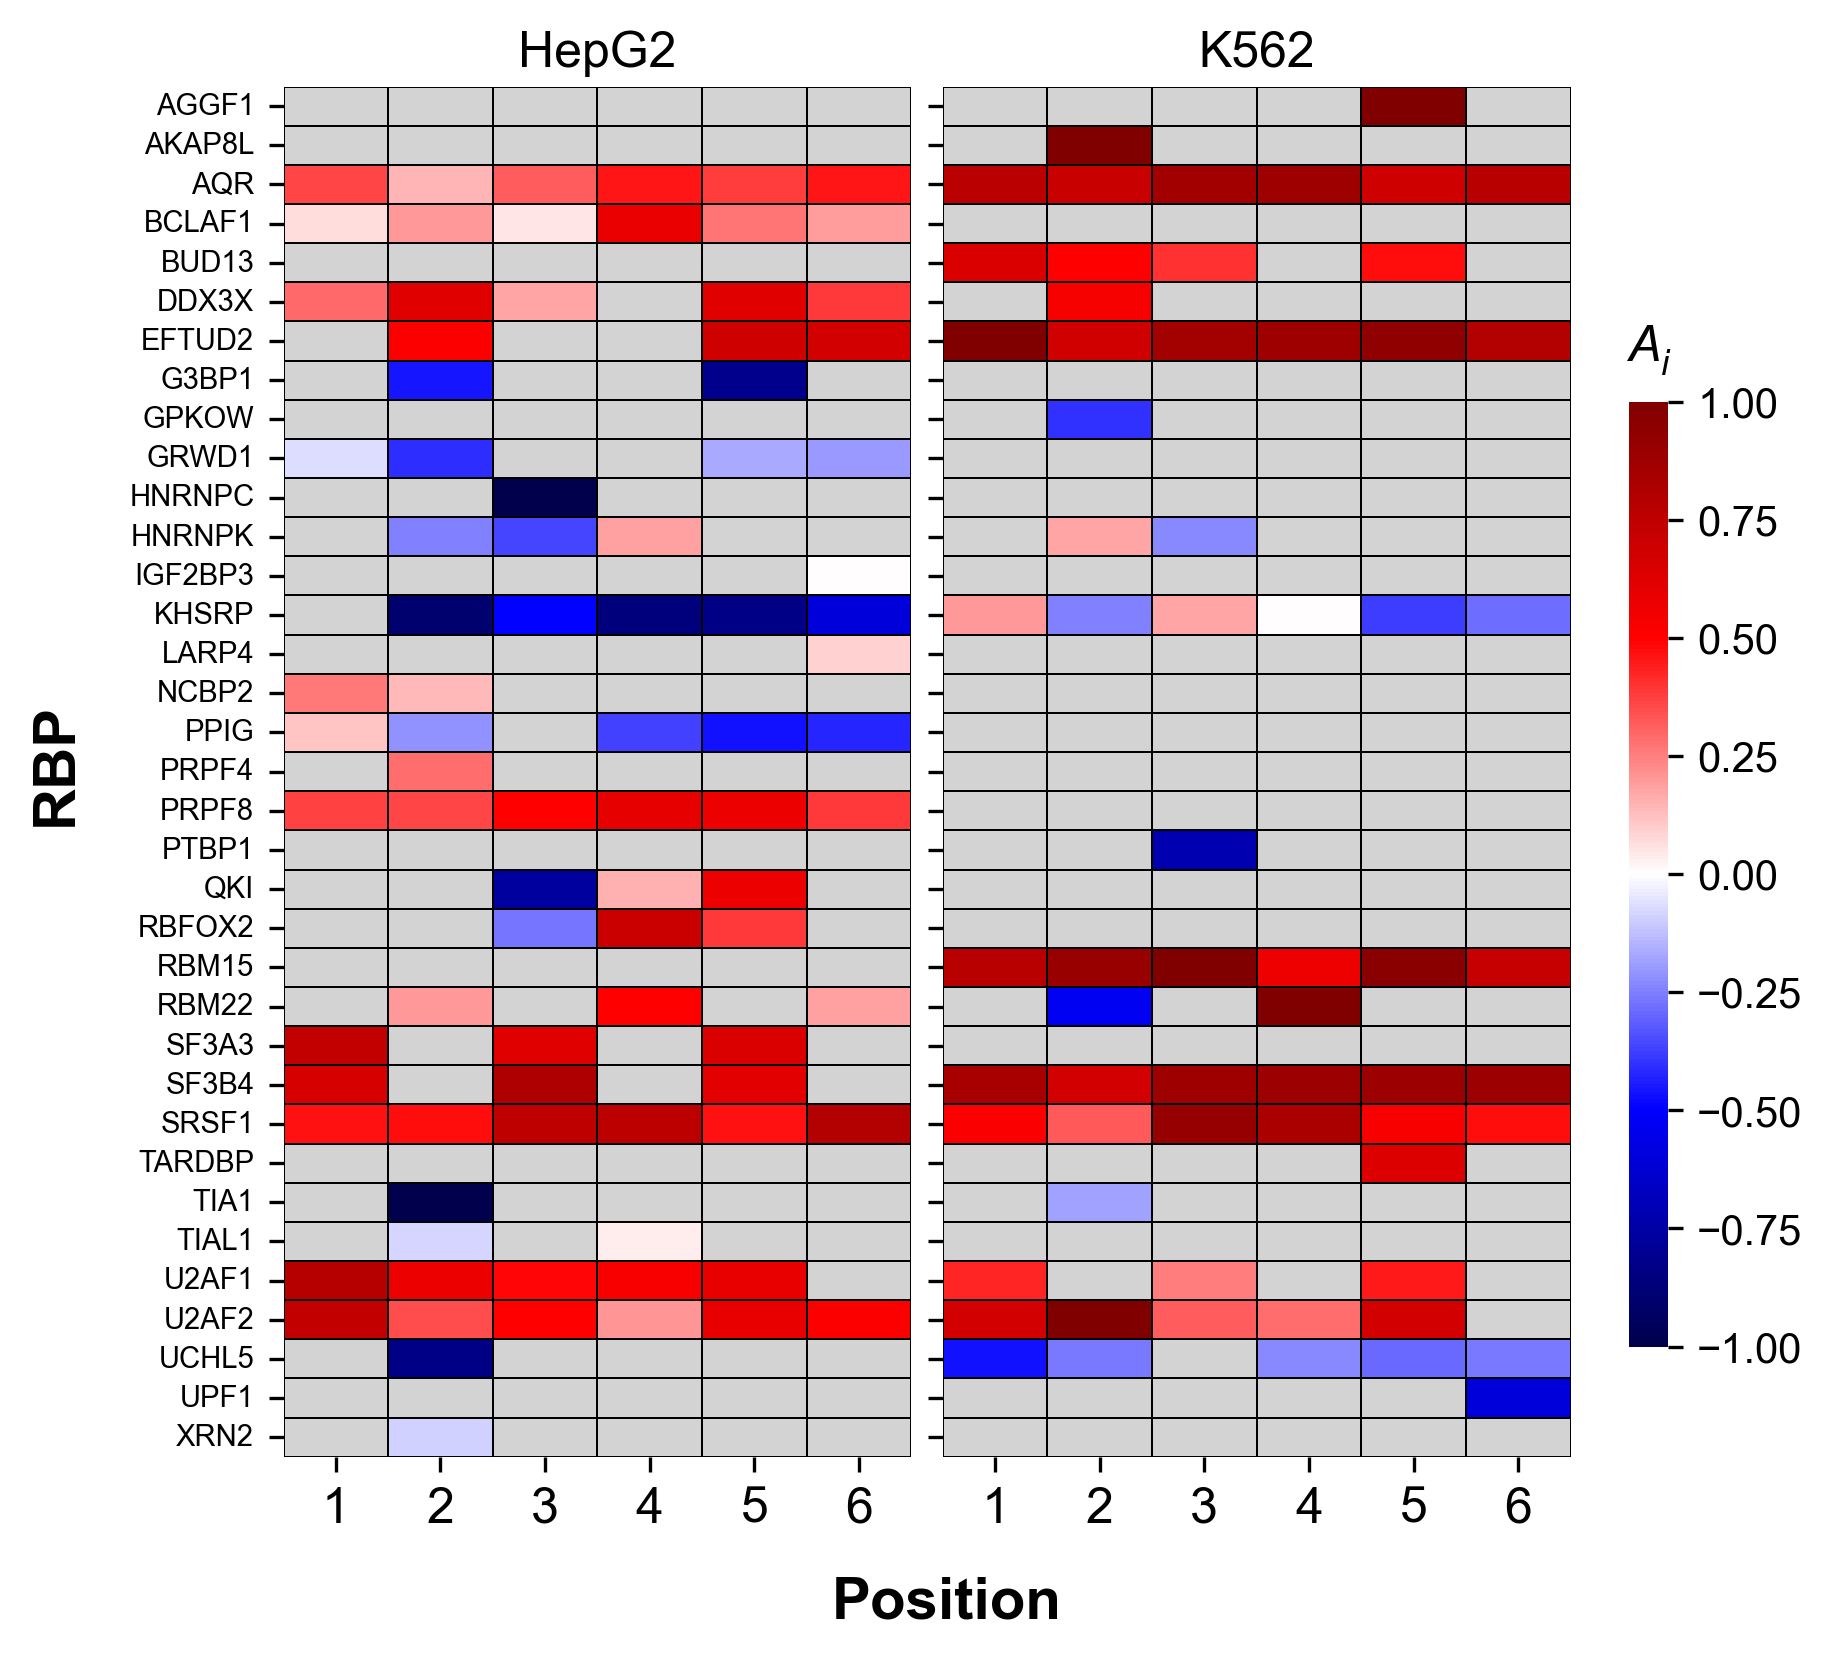

array([<Axes: title={'center': 'HepG2'}>,
       <Axes: title={'center': 'K562'}>], dtype=object)

In [20]:
plot_rbp_activity_heatmap_test(final_heatmap)

## SHAP vs RBP Activity Score Scatterplot

### This has the new SHAP data (log odds units)

In [14]:
glossary_data_path = f"/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_first_order_SHAP_analysis/outputs/specialized_global_SHAP/signed_local_SHAP_mean_bound_only_unique_binding.pkl"

with open(glossary_data_path, 'rb') as f:
        data = pickle.load(f)

In [15]:
keys = list(data.keys())

HepG2_glossary_raw = pd.DataFrame(data[keys[0]])
K562_glossary_raw = pd.DataFrame(data[keys[1]])

In [16]:
HepG2_glossary_raw.to_csv("/project/PlatigLab/users/reece/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/07_reece_biological_validations/1_shap_vs_dpsi_analysis/data/HepG2_new_glossary_heatmap.csv")
K562_glossary_raw.to_csv("/project/PlatigLab/users/reece/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/07_reece_biological_validations/1_shap_vs_dpsi_analysis/data/K562_new_glossary_heatmap.csv")

In [17]:
HepG2_glossary = pd.read_csv("/project/PlatigLab/users/reece/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/07_reece_biological_validations/1_shap_vs_dpsi_analysis/data/HepG2_new_glossary_heatmap.csv")
K562_glossary = pd.read_csv("/project/PlatigLab/users/reece/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/07_reece_biological_validations/1_shap_vs_dpsi_analysis/data/K562_new_glossary_heatmap.csv")

In [32]:
# Ignore zeros

def calculate_sign_concordance_no_zeros(cell_line):
    
    # Manipulate dataframes
    print(cell_line)
    t1 = globals()[f"{cell_line}_heatmap"].copy()
    t2 = globals()[f"{cell_line}_glossary"].T.copy()
    t2.columns = t2.columns + 1  # shift 0-5 → 1-6 to match t1
    
    t1.index.name = None
    t1.columns.name = None
    t2.index.name = None
    t2.columns.name = None
    
    print("t1 columns:", t1.columns.tolist())
    print("t2 columns:", t2.columns.tolist())
    
    common_proteins = t1.index.intersection(t2.index)
    t1 = t1.loc[common_proteins]
    t2 = t2.loc[common_proteins]
    
    t1, t2 = t1.align(t2, join="inner", axis=1)
    
    print(f"RBPs in common: {len(common_proteins)}")
    print(f"Positions being compared: {t1.shape[1]}")
    
    results = []
    total_match = 0
    total_valid = 0
    
    for protein in common_proteins:
        row1 = t1.loc[protein]
        row2 = t2.loc[protein]
    
        valid = row1.notna() & row2.notna() & (row1 != 0) & (row2 != 0)  # exclude zeros
        r1 = row1[valid]
        r2 = row2[valid]
    
        if len(r1) == 0:
            results.append({"protein": protein, "concordance": np.nan})
            continue
    
        matches = (np.sign(r1.values) == np.sign(r2.values)).sum()
        n        = len(r1)
        pct      = round(matches / n * 100, 2)
    
        total_match += matches
        total_valid += n
    
        results.append({"protein": protein, "concordance": pct})
    
    concordance_df = pd.DataFrame(results)
    total_concordance = round(concordance_df["concordance"].mean(), 2)
    
    print(f"\nTotal sign concordance across all proteins: {total_concordance}%\n")
    print(concordance_df.to_string(index=False))

    print(total_concordance)

    return total_concordance

In [33]:
K562_concordance = calculate_sign_concordance_no_zeros('K562')

K562
t1 columns: [1, 2, 3, 4, 5, 6]
t2 columns: [1, 2, 3, 4, 5, 6]
RBPs in common: 20
Positions being compared: 6

Total sign concordance across all proteins: 50.67%

protein  concordance
  AGGF1         0.00
 AKAP8L         0.00
    AQR        33.33
  BUD13        50.00
  DDX3X         0.00
 EFTUD2        66.67
  GPKOW       100.00
 HNRNPK        50.00
  KHSRP        80.00
  PTBP1       100.00
  RBM15        50.00
  RBM22       100.00
  SF3B4        33.33
  SRSF1        50.00
 TARDBP         0.00
   TIA1       100.00
  U2AF1         0.00
  U2AF2        20.00
  UCHL5        80.00
   UPF1       100.00
50.67


In [39]:
print(K562_concordance)

50.67


In [40]:
HepG2_concordance = calculate_sign_concordance_no_zeros('HepG2')

HepG2
t1 columns: [1, 2, 3, 4, 5, 6]
t2 columns: [1, 2, 3, 4, 5, 6]
RBPs in common: 27
Positions being compared: 6

Total sign concordance across all proteins: 46.54%

protein  concordance
    AQR        33.33
 BCLAF1        33.33
  DDX3X        20.00
 EFTUD2        33.33
  G3BP1       100.00
  GRWD1       100.00
 HNRNPC       100.00
 HNRNPK        66.67
IGF2BP3          NaN
  KHSRP       100.00
  LARP4         0.00
  NCBP2         0.00
   PPIG        40.00
  PRPF4         0.00
  PRPF8        33.33
    QKI        33.33
 RBFOX2        33.33
  RBM22        33.33
  SF3A3        33.33
  SF3B4        33.33
  SRSF1        16.67
   TIA1       100.00
  TIAL1        50.00
  U2AF1         0.00
  U2AF2        16.67
  UCHL5       100.00
   XRN2       100.00
46.54


In [38]:
HepG2_concordance

np.float64(46.54)

In [41]:
# Creating the source table

def rbp_activity_table(cell_line, data):
    
    print(cell_line)
    
    # Filter massive dataframe for KD samples, FDR <= 0.05, abs[DeltaPSI] >= 0.05

    filtered_data = (
        data
        .filter(
            (data["Sample Name"].str.contains("KD", literal=True))
            & (data["FDR"] <= 0.05)
            & (data["DeltaPSI"].abs() >= 0.05)
        )    
    )

    # Columns 
    columns_to_keep = [
        "RBP_KD_Target",
        "Sample Name",
        "FDR",
        "DeltaPSI",
        "has_RBP_KD_1",
        "has_RBP_KD_2",
        "has_RBP_KD_3",
        "has_RBP_KD_4",
        "has_RBP_KD_5",
        "has_RBP_KD_6",
        "Raw P-Val",
        "rMATS Event ID"
    ]
    
    rbp_targets = (
        filtered_data["RBP_KD_Target"]
        .unique()
        .sort()
        .to_list()
    )
    
    positions = [1,2,3,4,5,6]

    results = []  # collect all results here

    for rbp in rbp_targets:
        for pos in positions:

            rbp_specific_data = (
            filtered_data
            .filter(
                (pl.col("RBP_KD_Target") == rbp) & (pl.col(f"has_RBP_KD_{pos}") == True))
            .unique(subset=["rMATS Event ID"])) # gets in-silico KD rows per RBP per position

            # Drop unneccesary columns
            rbp_specific_data = rbp_specific_data.select(columns_to_keep)

            # Convert to pandas
            df = rbp_specific_data.to_pandas()

            # Prevents error for no data (SAFB or IGF..1)
            data = df["DeltaPSI"]

            if data.empty:
                continue 

            # DPSI conversion
            df["DeltaPSI"] = df["DeltaPSI"] * -1

            # Calculate the number of positive dPSI and the number of negative dPSI

            num_pos = (df["DeltaPSI"] > 0).sum()
            num_neg = (df["DeltaPSI"] < 0).sum()

            # Do not include rows plots with less than 10 sig. points 

            if (num_pos + num_neg) < 10:
                continue 

            # Normalized Difference Score
            norm_diff = (num_pos - num_neg) / (num_pos + num_neg)

            # Append results
            results.append({
                "RBP": rbp,
                "Position": pos,
                "num_pos": num_pos,
                "num_neg": num_neg,
                "norm_diff": norm_diff
            })

    # Final results dataframe
    results_df = pd.DataFrame(results)
    
    df = pd.DataFrame(results_df)

    glossary_data_path = f"/project/PlatigLab/users/reece/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/07_reece_biological_validations/1_shap_vs_dpsi_analysis/data/{cell_line}_new_glossary_heatmap.csv"

    glossary_data = pd.read_csv(glossary_data_path)
    
    # Melt glossary from wide to long so it matches activity data structure

    glossary_long = glossary_data.melt(id_vars="Position", var_name="RBP", value_name="shap")

    # Merge on position + RBP

    merged = df.merge(glossary_long, on=["RBP", "Position"], how="left")

    print(merged)

    pearson_corr = merged['norm_diff'].corr(merged['shap'], method='pearson')
    spearman_corr = merged['norm_diff'].corr(merged['shap'], method='spearman')

    print(f"Pearson correlation: {pearson_corr:.4f}")
    print(f"Spearman correlation: {spearman_corr:.4f}")

    sign_concordance_10_events_K562 = K562_concordance
    sign_concordance_10_events_HepG2 = HepG2_concordance

    sign_concordance_10_events = {
    "K562": sign_concordance_10_events_K562,
    "HepG2": sign_concordance_10_events_HepG2,
    }
    
    # Scatterplot
    conditions = [
        (merged["shap"] > 0) & (merged["norm_diff"] > 0),   # Q1
        (merged["shap"] < 0) & (merged["norm_diff"] > 0),   # Q2
        (merged["shap"] < 0) & (merged["norm_diff"] < 0),   # Q3
        (merged["shap"] > 0) & (merged["norm_diff"] < 0),   # Q4
    ]
    colors = ["red", "gray", "blue", "gray"]
    merged["quadrant_color"] = np.select(conditions, colors, default="black")
    label = r'$\bar{\varphi}^b_i$'
    score = r'$A_{i}$'
    plt.style.use("/project/PlatigLab/users/reece/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/07_reece_biological_validations/paper.mplstyle")
    plt.figure(figsize=(8, 6))
    plt.scatter(merged["shap"], merged["norm_diff"], c=merged["quadrant_color"], alpha=0.5)

    plt.xlim(-1.5, 1.3)
    plt.ylim(-1.05, 1.05)
    
    # Add horizontal & vertical lines at 0 to create 4 quadrants
    plt.axhline(0, color="black", linestyle="--", linewidth=1)
    plt.axvline(0, color="black", linestyle="--", linewidth=1)
    
    # Labels & title
    plt.xlabel(label, fontsize=21, labelpad=15)
    plt.ylabel(score, fontsize=21, labelpad=15)
    ax = plt.gca()
    ax.text(0.02, 0.97, f"{cell_line}", transform=ax.transAxes,
            fontsize=22, fontweight='bold', va='top', ha='left')
    
    # Pearson r on bottom-left
    ax.text(0.98, 0.03, f"Pearson r = {pearson_corr:.2f}",
            transform=ax.transAxes, fontsize=15, va='bottom', ha='right')
    
    # Sign concordance and Pearson
    ax.text(0.98, 0.09, f"Sign Concordance = {sign_concordance_10_events[cell_line]}",
            transform=ax.transAxes, fontsize=15, va='bottom', ha='right')
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.show()



HepG2
      RBP  Position  num_pos  num_neg  norm_diff      shap
0     AQR         1       30       14   0.363636 -0.068490
1     AQR         2       31       23   0.148148 -0.177027
2     AQR         3       27       14   0.317073  0.912755
3     AQR         4       24        9   0.454545  0.586993
4     AQR         5       51       23   0.378378 -0.150674
..    ...       ...      ...      ...        ...       ...
83  U2AF2         4       41       27   0.205882 -0.305160
84  U2AF2         5      323       84   0.587224 -0.156785
85  U2AF2         6       25        8   0.515152 -0.048858
86  UCHL5         2        1       11  -0.833333 -0.415896
87   XRN2         2        5        6  -0.090909 -0.284059

[88 rows x 6 columns]
Pearson correlation: 0.1989
Spearman correlation: 0.1804


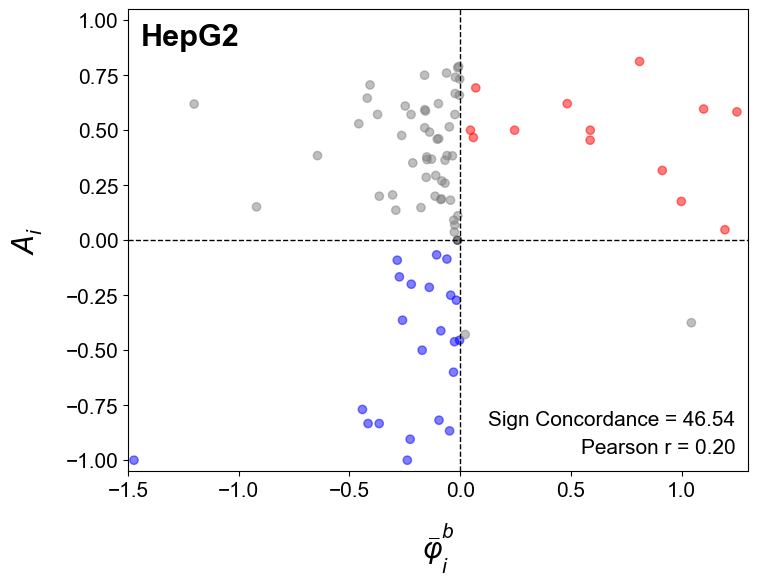

In [42]:
hepg2_data = rbp_activity_table('HepG2', all_model_data_HepG2)

K562
       RBP  Position  num_pos  num_neg  norm_diff      shap
0    AGGF1         5       13        0   1.000000 -0.009366
1   AKAP8L         2       12        0   1.000000 -0.000870
2      AQR         1      249       33   0.765957 -0.016039
3      AQR         2     1172      192   0.718475 -0.231833
4      AQR         3      340       25   0.863014  0.517747
..     ...       ...      ...      ...        ...       ...
60   UCHL5         2       10       17  -0.259259 -0.208452
61   UCHL5         4        5        8  -0.230769  0.923129
62   UCHL5         5        6       11  -0.294118 -0.173603
63   UCHL5         6        7       12  -0.263158 -0.081410
64    UPF1         6        2        8  -0.600000 -0.024331

[65 rows x 6 columns]
Pearson correlation: 0.2773
Spearman correlation: 0.4095


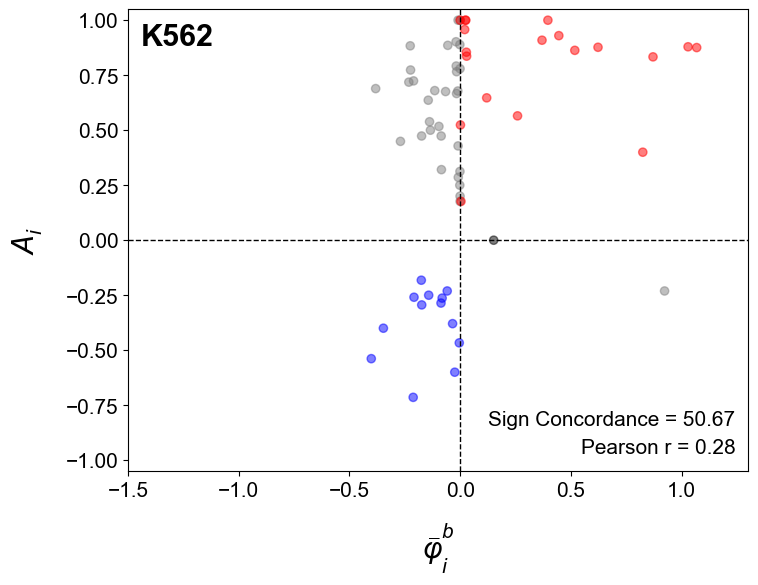

In [43]:
k562_data = rbp_activity_table('K562', all_model_data_K562)